In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv('.env')
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
    api_key=os.getenv('api_key')
)
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DCF3EF9570>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DCF3EF9480>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
# Agent to respond on emails
# (first agent Triage filter email then
# if its good email pass to ReAct Agent to use available tools and respond)
# if its spam email dont pass to ReAct Agent
# if its important email to notify so (notify: but will leave it empty in this code)

# First thing after Schema drawn is prompts:
## prompts
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated

profile = {
    "name": "John",
    "full_name": "John Doe",
    "user_profile_background": "Senior software engineer leading a team of 5 developers",
}

prompt_instructions = {
    "triage_rules": {
        "ignore": "Marketing newsletters, spam emails, mass company announcements",
        "notify": "Team member out sick, build system notifications, project status updates",
        "respond": "Direct questions from team members, meeting requests, critical bug reports",
    },
    "agent_instructions": "Use these tools when appropriate to help manage User's tasks efficiently."
}

# Example incoming email
email = {
    "from": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "body": """
Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

# schema for Router Model (classify & resoning why this classification)
class Router(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

llm_router = llm.with_structured_output(Router) # Tagging
llm_router

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DCF3EF9570>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DCF3EF9480>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Router', 'description': 'Analyze the unread email and route it according to its content.', 'parameters': {'properties': {'reasoning': {'description': 'Step-by-step reasoning behind the classification.', 'type': 'string'}, 'classification': {'description': "The classification of an email: 'ignore' for ir

In [3]:
# prepare prompts (could be from langsmith hub also)
import importlib
import email_task_templates

importlib.reload(email_task_templates) # to handle pycache the module
triage_system_prompt = email_task_templates.triage_system_prompt
triage_user_prompt = email_task_templates.triage_user_prompt
print(triage_system_prompt)


< Role >
You are {full_name}'s executive assistant. You are a top-notch executive assistant who cares about {name} performing as well as possible.
</ Role >

< Background >
{user_profile_background}. 
</ Background >

< Instructions >

{name} gets lots of emails. Your job is to categorize each email into one of three categories:

1. IGNORE - Emails that are not worth responding to or tracking
2. NOTIFY - Important information that {name} should know about but doesn't require a response
3. RESPOND - Emails that need a direct response from {name}

Classify the below email into one of these categories.

</ Instructions >

< Rules >
Emails that are not worth responding to:
{triage_no}

There are also other things that {name} should know about, but don't require an email response. For these, you should notify {name} (using the `notify` response). Examples of this include:
{triage_notify}

Emails that are worth responding to:
{triage_email}
</ Rules >

< Few shot examples >
{examples}
</ Fe

In [4]:
# now modify this template to be prompt
system_prompt = triage_system_prompt.format(
    full_name=profile["full_name"],
    name=profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

# try out the llm
result = llm_router.invoke(
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
)
result

Router(reasoning='The email is a direct question from a team member, Alice Smith, regarding API documentation, which requires a response from John to clarify the issue.', classification='respond')

In [5]:
#### Define Main Agent now (ReAct) to solve the task using tools
# First tools & llm.bind_tools()
# Second AgentState across Graph
# Third build Graph (node for LLM and node for execute)

# First tools
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict
from typing import Annotated
import operator

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}'"

@tool
def schedule_meeting(
    attendees: list[str], 
    subject: str, 
    duration_minutes: int, 
    preferred_day: str
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    return f"Meeting '{subject}' scheduled for {preferred_day} with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"



#### a) Semantic Memory:

* 1) configure memory tools (specfic namespace for each user)

* 2) define config

In [6]:
# * 1) configure memory tools (specfic namespace for each user)

# quick fix (langmem require python 3.11 but I have 3.10 so solve with sht solns)
import typing
import typing_extensions

if not hasattr(typing, "NotRequired"):
    typing.NotRequired = typing_extensions.NotRequired  # backport it

from langmem import create_manage_memory_tool, create_search_memory_tool
manage_memory_tool = create_manage_memory_tool(
    namespace=(
        "email_assistant", 
        "{langgraph_user_id}",
        "collection"
    )
)
search_memory_tool = create_search_memory_tool(
    namespace=(
        "email_assistant",
        "{langgraph_user_id}",
        "collection"
    )
)

print(f"manage_memory_tool.name: {manage_memory_tool.name}")
print(f"manage_memory_tool.args: {manage_memory_tool.args}")
print(f"manage_memory_tool.description: {manage_memory_tool.description}")
print("\n" + '*'*50 + '\n')
print(f"search_memory_tool.name: {search_memory_tool.name}")
print(f"search_memory_tool.args: {search_memory_tool.args}")
print(f"search_memory_tool.description: {search_memory_tool.description}")

tools = [write_email, schedule_meeting, check_calendar_availability, manage_memory_tool, search_memory_tool]

manage_memory_tool.name: manage_memory
manage_memory_tool.args: {'content': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Content'}, 'action': {'default': 'create', 'enum': ['create', 'update', 'delete'], 'title': 'Action', 'type': 'string'}, 'id': {'anyOf': [{'format': 'uuid', 'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Id'}}
manage_memory_tool.description: Create, update, or delete a memory to persist across conversations.
Include the MEMORY ID when updating or deleting a MEMORY. Omit when creating a new MEMORY - it will be created for you.
Proactively call this tool when you:

1. Identify a new USER preference.
2. Receive an explicit USER request to remember something or otherwise alter your behavior.
3. Are working and want to record important context.
4. Identify that an existing MEMORY is incorrect or outdated.

**************************************************

search_memory_tool.name: search_memory
search_memory_tool.args: {'

c:\Users\ahmed\anaconda3\envs\agentic_env\lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [7]:
# Second AgentState across whole Graph
class AgentState(TypedDict):
    messages : Annotated[list[BaseMessage], operator.add]
    email_input: dict

In [8]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import Literal

# Third build Graph (node for LLM and node for execute)
class EmailRespondAgent:

    def __init__(self, llm, tools, memories, system_prompt=""):
        self.llm = llm
        self.tools_map = {tool.name: tool for tool in tools}
        self.system_prompt = system_prompt
        self.llm_router = llm.with_structured_output(Router)
        self.llm_with_tools  = llm.bind_tools(tools)
        graph = StateGraph(AgentState)
        graph.add_node("triage_router",  self.llm_router_node)
        graph.add_node('response_agent', self.response_agent)
        graph.add_node('execute_tool', self.execute_tool)

        # Edges
        graph.add_edge(START, "triage_router")   # entry point
        graph.add_conditional_edges('response_agent', self.should_continue, {True:'execute_tool', False: END})
        graph.add_edge('execute_tool', 'response_agent')
        self.graph = graph.compile(checkpointer=memories['short_term_memory'], store=memories['long_term_memory'])

    def llm_router_node(self, state: AgentState) -> Command[Literal['response_agent', '__end__']]:
        author = state['email_input']['author']
        to = state['email_input']['to']
        subject = state['email_input']['subject']
        email_thread = state['email_input']['email_thread']

        system_prompt = triage_system_prompt.format(
            full_name=profile["full_name"],
            name=profile["name"],
            user_profile_background=profile["user_profile_background"],
            triage_no=prompt_instructions["triage_rules"]["ignore"],
            triage_notify=prompt_instructions["triage_rules"]["notify"],
            triage_email=prompt_instructions["triage_rules"]["respond"],
            examples=None
        )
        user_prompt = triage_user_prompt.format(
            author=author, 
            to=to, 
            subject=subject, 
            email_thread=email_thread
        )
        response = self.llm_router.invoke(
            [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ]
        )
        response_clf = response.classification
        if response_clf == 'respond':
            print("📧 Classification: RESPOND - This email requires a response")
            goto = 'response_agent'
            update = {
                "messages": [HumanMessage(content=f"Respond to the email {state['email_input']}")] # passing in messages a HumanMessage with email_input
            }

        elif response_clf == 'ignore':
            print("🚫 Classification: IGNORE - This email can be safely ignored")
            goto = END
            update = None # dont update

        elif response_clf == 'notify':
            # If real life, this would do something else
            print("🔔 Classification: NOTIFY - This email contains important information")
            goto = END
            update = None # dont update

        else:
            raise ValueError(f"Invalid classification: {result.classification}")

        return Command(goto=goto, update=update)

    def response_agent(self, state: AgentState):
        messages = state['messages']
        if self.system_prompt:
            messages = [SystemMessage(content=self.system_prompt)] + messages
        response = self.llm_with_tools.invoke(messages)
        return {'messages': [response]}
    
    def execute_tool(self, state: AgentState):
        last_message = state['messages'][-1]
        tool_results = []
        for tool_call in last_message.tool_calls:
            tool_fn = self.tools_map[tool_call["name"]]
            result  = tool_fn.invoke(tool_call["args"])
            tool_results.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=tool_call["id"],
                    name=tool_call["name"],
                )
            )
        return {"messages": tool_results}
    
    def should_continue(self, state: AgentState):
        last_message = state["messages"][-1]
        if last_message.tool_calls:
            return True
        return False

In [9]:
# * 2) define config
# define embedding for long_term_memory
from langchain_ollama import OllamaEmbeddings
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.sqlite import SqliteStore
import sqlite3

embedding_model = OllamaEmbeddings(model="nomic-embed-text")

conn = sqlite3.connect("email_respond_agent_short_term_memory.db", check_same_thread=False)
short_term_memory = SqliteSaver(conn)

# Long-term
conn_long = sqlite3.connect("email_respond_agent_long_term_memory.db", check_same_thread=False,
                            isolation_level=None # ← fixes the transaction error
)
long_term_memory = SqliteStore(
    conn_long,
    index={"embed": embedding_model, "dims": 768}
)

memories = {'long_term_memory': long_term_memory, 'short_term_memory': short_term_memory}

system_prompt = email_task_templates.react_agent_system_prompt.format(instructions=prompt_instructions['agent_instructions'], **profile)
email_respond_multiagent = EmailRespondAgent(llm=llm, tools=tools, memories=memories, system_prompt=system_prompt)
email_respond_multiagent

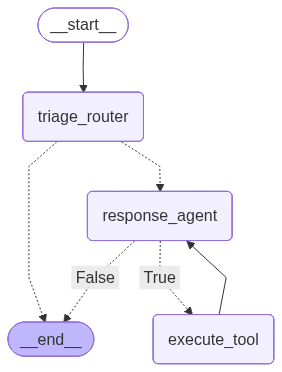

In [10]:
email_respond_multiagent.graph

In [11]:
# example_1
email_input = {
    "author": "Marketing Team <marketing@amazingdeals.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "🔥 EXCLUSIVE OFFER: Limited Time Discount on Developer Tools! 🔥",
    "email_thread": """Dear Valued Developer,

Don't miss out on this INCREDIBLE opportunity! 

🚀 For a LIMITED TIME ONLY, get 80% OFF on our Premium Developer Suite! 

✨ FEATURES:
- Revolutionary AI-powered code completion
- Cloud-based development environment
- 24/7 customer support
- And much more!

💰 Regular Price: $999/month
🎉 YOUR SPECIAL PRICE: Just $199/month!

🕒 Hurry! This offer expires in:
24 HOURS ONLY!

Click here to claim your discount: https://amazingdeals.com/special-offer

Best regards,
Marketing Team
---
To unsubscribe, click here
""",
}
config = {"configurable": {"thread_id": "1", "langgraph_user_id": "specific_user_id"}}
# * 2) define config
# thread_id: short-term memory (conversation only)
# langgraph_user_id: long-term memory (facts about user from many chats)
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

🚫 Classification: IGNORE - This email can be safely ignored
None


In [12]:
# example_2
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}
config = {"configurable": {"thread_id": "1", "langgraph_user_id": "specific_user_id"}}
# * 2) define config
# thread_id: short-term memory (conversation only)
# langgraph_user_id: long-term memory (facts about user from many chats)
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

📧 Classification: RESPOND - This email requires a response
{'messages': [HumanMessage(content='Respond to the email {\'author\': \'Alice Smith <alice.smith@company.com>\', \'to\': \'John Doe <john.doe@company.com>\', \'subject\': \'Quick question about API documentation\', \'email_thread\': "Hi John,\\n\\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\\n\\nSpecifically, I\'m looking at:\\n- /auth/refresh\\n- /auth/validate\\n\\nThanks!\\nAlice"}', additional_kwargs={}, response_metadata={})]}
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ehrgh3982', 'function': {'arguments': '{"content":"Hi Alice, \\n\\nThank you for reaching out. I\'ll review the API documentation for the new authentication service and get back to you regarding the missing endpoints. \\n\\nBest, \\nJohn Doe","subject":"R

In [13]:
# example_3 check if task is created for this user
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

Hello John,

I was asking about follow-up on my previouse email please.

Thanks!
Alice""",
}
config = {"configurable": {"thread_id": "1", "langgraph_user_id": "specific_user_id"}}
# * 2) define config
# thread_id: short-term memory (conversation only)
# langgraph_user_id: long-term memory (facts about user from many chats)
for event in email_respond_multiagent.graph.stream({"email_input": email_input}, config):
    for v in event.values():
        print(v)

📧 Classification: RESPOND - This email requires a response
{'messages': [HumanMessage(content="Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': 'Hi John,\\n\\nHello John,\\n\\nI was asking about follow-up on my previouse email please.\\n\\nThanks!\\nAlice'}", additional_kwargs={}, response_metadata={})]}
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qjtxrb0fg', 'function': {'arguments': '{"content":"Hi Alice, \\n\\nI apologize for the delay in my response. I had sent a response earlier and I\'m following up on it now. I\'m still reviewing the API documentation for the new authentication service regarding the missing endpoints (/auth/refresh and /auth/validate) you mentioned. I\'ll get back to you as soon as possible. \\n\\nBest, \\nJohn Doe","subject":"Re: Quick question about API documentation","to":"alice.smith@company.c